# Online Retail — KMeans Customer Segmentation

This notebook performs EDA, preprocessing, RFM feature engineering, and KMeans clustering for customer segmentation using the provided **Online Retail** dataset.

It includes:
- Data loading & cleaning
- Exploratory Data Analysis (missing values, basic stats)
- RFM feature creation (Recency, Frequency, Monetary)
- Scaling, elbow method, silhouette analysis
- KMeans fitting and cluster inspection
- PCA visualization of clusters

In [1]:
import pandas as pd
from datetime import timedelta

df = pd.read_excel("Online Retail.xlsx")
print("Loaded dataset shape:", df.shape)
df.head()

Loaded dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# Basic EDA
print("Columns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nDescribe numeric:\n", df.describe())

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Data types:
 InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Describe numeric:
             Quantity                    InvoiceDate      UnitPrice  \
count  541909.000000                         541909  541909.000000   
mean        9.552250  2011-07-04 13:34:57.156386048       4.611114   
min    -80995.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000            2011-03-28 11:34:00       1.250000   
50%         3.000000            2011-07

In [3]:
# Cleaning
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df_clean = df[~df['InvoiceNo'].astype(str).str.startswith('C')].copy()
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)].copy()
df_clean = df_clean.dropna(subset=['CustomerID'])
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
print("Cleaned shape:", df_clean.shape)
df_clean.head()

Cleaned shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [4]:
# RFM aggregation
snapshot_date = df_clean['InvoiceDate'].max() + timedelta(days=1)
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index().rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
})
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


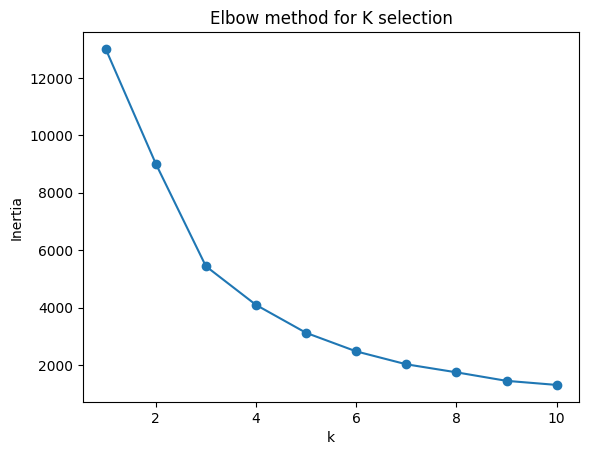

Silhouette scores (k=2..10): {2: 0.8958167182320717, 3: 0.5941879366550106, 4: 0.616212846765192, 5: 0.6165231087744963, 6: 0.5963168804095496, 7: 0.5164702399121812, 8: 0.5174591797377505, 9: 0.47773236230395444, 10: 0.42714342150727336}
Selected k (max silhouette): 2
Cluster centers (original scale):
   Recency  Frequency  Monetary  Cluster
0    93.06       3.90   1548.68        0
1     6.04      66.42  85904.35        1


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(list(K_range), inertia, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method for K selection')
plt.show()

# Silhouette scores
sil_scores = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores[k] = sil
print("Silhouette scores (k=2..10):", sil_scores)

best_k = max(sil_scores, key=sil_scores.get)
print("Selected k (max silhouette):", best_k)

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Cluster centers
centers = scaler.inverse_transform(kmeans_final.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=features).round(2)
centers_df['Cluster'] = centers_df.index
print("Cluster centers (original scale):")
print(centers_df)

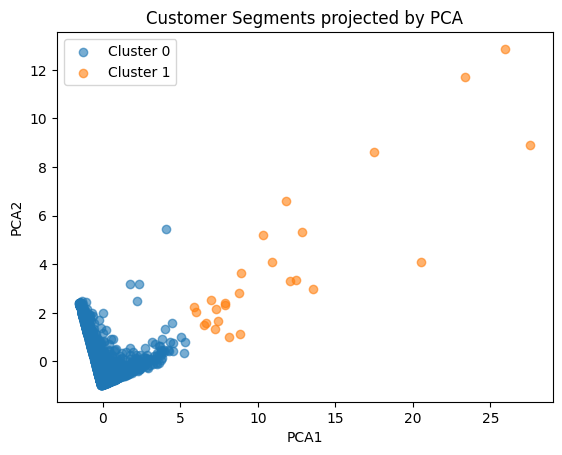

In [6]:
# PCA visualization
pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(X_scaled)
rfm['PCA1'] = proj[:,0]
rfm['PCA2'] = proj[:,1]

for c in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster']==c]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=f"Cluster {c}", alpha=0.6)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Customer Segments projected by PCA')
plt.legend()
plt.show()

## Summary of findings

- Dataset loaded and cleaned for cancelled orders, negative quantities/prices, and missing customer IDs.
- RFM (Recency, Frequency, Monetary) features created for each customer.
- Features scaled and optimal K chosen via silhouette scores.
- KMeans clustering performed and cluster centers interpreted.
- PCA used for 2D visualization of clusters.

Next steps:
- Apply log transformation to reduce skew in Monetary.
- Try other clustering methods (DBSCAN, Gaussian Mixture).
- Label clusters for business interpretation (e.g., "Loyal High Spenders").